# The spelled-out intro to neural networks and backpropagation: building micrograd

📺 **Video:** [The spelled-out intro to neural networks and backpropagation: building micrograd](https://youtu.be/VMj-3S1tku0)

> Micrograd notu buraya yazılacak.

In [1]:
# @author ypatoglu
print("merhaba")

merhaba


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Derivative of a simple function with one input

`3x² - 4x + 5`. Normalde lise matematiğiyle bunun türevini alıp içine değerleri yazardık; sembolik bir hesaplama olurdu. Ancak burada bunu yapmayacağız, çünkü neural network'lerde bunu yaparsak çok büyük bir expression çıkar.

Türevi bir noktada limit tanımıyla şöyle bulabiliriz: bir değişkene göre türev almak istiyorsak, o değişkeni çok çok küçük bir miktar (`h`) kadar arttırırız. Yani bizim örneğimizde `x`'i çok ufak arttıralım, sonra bunu fonksiyona verelim. Ardından bulduğumuz sonuçtan ilk değeri çıkarıp, arttırdığımız bu küçük `h` sayısına bölelim:

```
[f(x + h) - f(x)] / h
```

Bu bize aslında o noktadaki çok küçük bir üçgende `tan α`'yı, yani eğimi veriyor. Bu da şunu söylüyor: fonksiyonda `x`'i ufacık oynatırsam, fonksiyon o yönde ne derecede ve hangi yönde tepki verir. Kısaca good old türev tanımı.

In [3]:
def f(x):
    return 3*x*x - 4*x + 5

In [4]:
f(3.0)

20.0

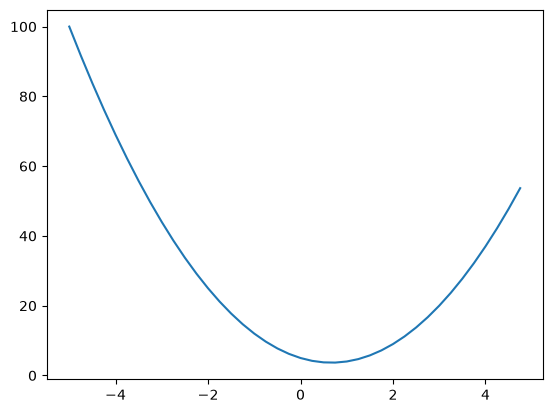

In [5]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [6]:
h = 0.000001
x = -3
slope_at_3 =  (f(x+h) - f(x)) / h
print(slope_at_3)

h = 0.0000001
slope_at_3 = (f(3 + h) - f(3)) / h
print(slope_at_3)

-21.999997002808414
14.000000305713911


## Derivative of a function with multiple inputs

Şimdi buraya bakalım: burada çok değişkenli fonksiyonlar var.

`d = a*b + c` fonksiyonunun kısmi türevleri:

- `a`'ya göre türevi → `b`
- `b`'ye göre türevi → `a`
- `c`'ye göre türevi → `1`

Karpathy bunu yine limit tanımını uygulayarak gösteriyor; aynı zamanda biz bunu türev kurallarından da doğrulayabiliyoruz.

In [7]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

def f(a, b, c):
    return a * b + c

slope_at_a = ( (f(a + h, b, c)) - f(a, b, c)) / h

print(f(a, b, c) + h)

print(f(a, b, c))

print(slope_at_a)



4.0001
4.0
-3.000000000010772


In [8]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


## Starting the core `Value` object

Burada `Value` isimli bir class tanımlıyoruz. `print`, `+` ve `*` için **operator overloading** yapıyoruz:

- `__repr__` → `print(a)` ya da hücrede `a` yazdığımızda ne göreceğimizi belirler; olmasaydı `<__main__.Value object at 0x7f...>` gibi bir çıktı alırdık.
- `__add__` → `a + b` yazdığımızda Python arka planda `a.__add__(b)` çağırır.
- `__mul__` → `a * b` yazdığımızda `a.__mul__(b)` çağrılır.

Sayesinde `d = a*b + c` gibi normal matematik sözdizimiyle expression kurabiliyoruz. `a*b` önce bir `Value` döndürüyor, sonra ona `+ c` uygulanıyor.

### `_children` ve `_op`

Şimdi de `_children` ve `_op` field'larını ekliyoruz. Bu sayede o `Value`'yu oluşturan `Value` objelerini (2 tane) — yani **left ve right operand'ı** — tutuyoruz. Aynı zamanda bu iki operand'ın arasındaki operatörü de `*` veya `+` şeklinde not ediyoruz.

```python
def __init__(self, data, _children=(), _op=''):
    self.data  = data
    self._prev = set(_children)
    self._op   = _op
```

- `_children` boş tuple `()` default'uyla geliyor; `a = Value(2.0)` gibi **yaprak** node'ların çocuğu yok.
- `__add__` ve `__mul__` sonucu üretirken `(self, other)` tuple'ını ve operatörü de veriyor:
  `Value(self.data * other.data, (self, other), '*')`
- `_op` yaprak node'larda boş string kalıyor — o node bir işlemden doğmadı demek.

Böylece her `Value` kendisini kimin ürettiğini biliyor. Bu bağlantılar birleşince ortaya **expression graph** çıkıyor; `d._prev` dersek `a*b` ile `c`'yi görürüz. Backpropagation'da bu grafikte tersten yürüyeceğiz.

In [9]:
class Value:

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [10]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c
d

Value(data=4.0)

## Visualizing the expression graph

Burada ise final `Value` objesini alıp expression graph'ını çizen bir fonksiyon var. Grafiği `graphviz` ile görselleştiriyoruz.

İki parça:

- **`trace(root)`** — `root`'tan başlayıp `_prev` bağlantılarını rekürsif olarak takip ediyor ve grafikteki tüm node'lar ile edge'leri topluyor. `if v not in nodes` kontrolü aynı node'u iki kez gezmeyi (ve sonsuz döngüyü) engelliyor.
- **`draw_dot(root)`** — topladığı node ve edge'leri Digraph'a çeviriyor.

Çizim detayları:

- `rankdir: 'LR'` → grafik soldan sağa akıyor (input'lar solda, sonuç sağda).
- Her `Value` için dikdörtgen (`record`) bir node çiziliyor, içinde `data` değeri.
- Node bir işlemden doğduysa (`_op` boş değilse) **ayrı bir operatör node'u** (`*` veya `+`) oluşturuluyor ve sonuca bağlanıyor. Bu yüzden grafikte yuvarlak op node'ları görüyoruz.
- `str(id(n))` her node'a benzersiz bir isim veriyor; graphviz'in node'ları ayırt etmesi için gerekli.
- Edge'ler `n1 → n2`'nin **op node'una** bağlanıyor, doğrudan `n2`'ye değil — böylece "iki operand op'a girer, op'tan sonuç çıkar" akışı oluşuyor.

In [11]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ data %.4f }" % (n.data, ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

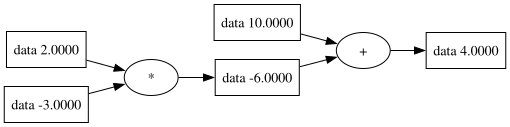

In [12]:
draw_dot(d)

## Adding labels

**Neden?** Grafiği çizdiğimizde node'ların hangi değişken olduğunu göremiyoruz. Kutularda sadece `data -6.0000` yazıyor; bunun `a*b` sonucu mu, başka bir ara değer mi olduğunu ayırt edemiyoruz. Expression büyüdükçe grafik okunamaz hâle geliyor.

Çözüm: her `Value`'ya bir isim (`label`) verelim ve çizerken kutuya yazdıralım.

**Ne değişti?** İki yerde ufak dokunuş.

`Value.__init__` bir alan daha alıyor:

```diff
- def __init__(self, data, _children=(), _op=''):
+ def __init__(self, data, _children=(), _op='', label=''):
      self.data = data
      self._prev = set(_children)
      self._op = _op
+     self.label = label
```

`draw_dot` içindeki node etiketi iki bölmeli hâle geliyor — `record` shape'i `|` karakteriyle kutuyu bölüyor:

```diff
- dot.node(name=uid, label="{ data %.4f }" % (n.data, ), shape='record')
+ dot.node(name=uid, label="{ %s | data %.4f }" % (n.label, n.data), shape='record')
```

`label` default'u boş string olduğu için, isim vermediğimiz node'lar eskisi gibi çalışmaya devam eder — sadece kutunun sol bölmesi boş görünür.

In [13]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [14]:
def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # artik kutuda once label, sonra data var: { a | data 2.0000 }
        dot.node(name=uid, label="{ %s | data %.4f }" % (n.label, n.data), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [15]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

Dikkat: `e = a*b` satırında `label`'ı constructor'a veremiyoruz, çünkü `e` bir işlemin sonucu — `__mul__` içinde `Value` oluşturuluyor. O yüzden sonradan `e.label = 'e'` diye atıyoruz.

Artık grafikte hangi kutunun hangi değişken olduğu net görünüyor.

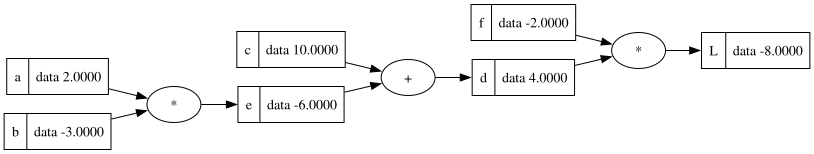

In [16]:
draw_dot(L)

## Adding `grad`

**Neden?** Her `Value`'nun, çıktıyı (`L`) ne kadar etkilediğini bir yerde tutmamız lazım. Bu da `grad` alanı: `a.grad` aslında `dL/da` demek — *"`a`'yı ufacık oynatırsam `L` ne kadar değişir?"*

En başta `self.grad`'ı **0** yapıyoruz, çünkü daha her `Value` objesi için grad'ı hesaplamadık. Sıfır burada "etkisi yok" anlamına geliyor: gradyan sıfırsa o değeri değiştirmek loss'u değiştirmez. Yani başlangıçta *hiçbir değer çıktıyı etkilemiyor* varsayımıyla yola çıkıyoruz; backpropagation çalışınca bu sıfırlar gerçek değerlerle dolacak.

Sıfır seçmemizin iki pratik sebebi de var:

- **Güvenli.** Eğitim adımı `p.data += -lr * p.grad` şeklinde olacak. Grad sıfırken bu satır hiçbir şey yapmaz — backprop'u çalıştırmayı unutsak bile ağırlıklar rastgele savrulmaz.
- **Toplama için gerekli.** Bir değer expression'da birden fazla yerde kullanılabilir; o zaman gradyanı her yoldan gelen katkının toplamı olmalı. Kod ilerde `=` yerine `+=` kullanacak, toplamaya da sıfırdan başlamak gerekir.

**Ne değişti?** `__init__`'e tek satır:

```diff
  def __init__(self, data, _children=(), _op='', label=''):
      self.data = data
+     self.grad = 0.0
      self._prev = set(_children)
      self._op = _op
      self.label = label
```

Bir de grafikte görebilmek için kutuya üçüncü bir bölme ekliyoruz:

```diff
- dot.node(name=uid, label="{ %s | data %.4f }" % (n.label, n.data), shape='record')
+ dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
```

`trace` fonksiyonuna dokunmuyoruz — o sadece grafiği geziyor, ne yazdığıyla ilgilenmiyor. Değişiklik tamamen çizim tarafında.

Şimdi grafiği çizersek bütün kutularda `grad 0.0000` göreceğiz. Doğrusu da bu: henüz backprop yapmadık.

In [17]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [18]:
def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # kutu artik uc bolmeli: { a | data 2.0000 | grad 0.0000 }
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
                 shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

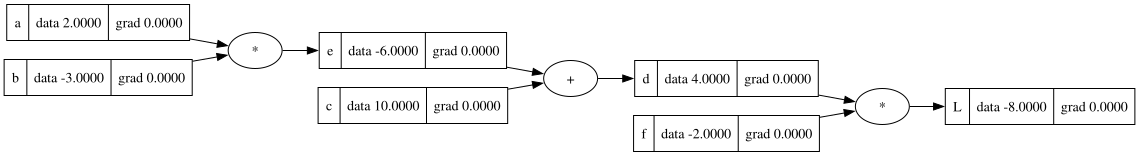

In [19]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'

draw_dot(L)

## Numerical gradient: `lol()`

Şimdi Karpathy bu fonksiyonu koyuyor. Yaptığı şey şu: tüm expression'da, gradyanını bulmak istediği değişkeni `h` kadar artırıyor, ardından yeni loss'u hesaplayıp aradaki farkı `h`'a bölüyor. Böylece o değişkenin gradyanını buluyor.

Yani en baştaki limit tanımının aynısı, sadece bu sefer tek bir sayı yerine koca bir expression'ın sonunda:

```
[L(a + h) - L(a)] / h
```

Fonksiyon expression'ı **iki kez** kuruyor: birincisinde her şey normal (`L1`), ikincisinde sadece ilgilendiğimiz değişken `h` kadar fazla (`L2`). Aradaki farkı `h`'a bölünce `dL/da` çıkıyor.

### Neden bir fonksiyonun içinde? (local vs global scope)

Notebook'ta yukarıda zaten global `a`, `b`, `c`, `d`, `e`, `f`, `L` değişkenleri var. Fonksiyon içinde atama yapınca değişkenler **local scope**'ta kalıyor, dışarıdaki aynı isimli globallere dokunulmuyor.

Bu kodu doğrudan hücreye yazsaydık globaldeki `a`'nın üstüne `2.0 + h` yazılırdı ve sonraki `draw_dot(L)` bambaşka bir grafik verirdi.

> `lol` anlamlı bir isim değil, Karpathy gelişigüzel seçiyor.


In [20]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0 + h, label='a')   # gradyanini istedigimiz degiskeni h kadar artir
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol()

6.000000000021544


Sonuç `6.000000000021544` çıkıyor. Elle kontrol edelim: `L = (a·b + c)·f` olduğuna göre

```
dL/da = b · f = (-3) · (-2) = 6
```

Tutuyor. Sondaki `...0215` ise floating-point hatası — sonlu farklar yönteminin doğası gereği sonuç hep yaklaşık.

Hangi değişkenin gradyanını istiyorsak `+ h`'ı oraya taşıyoruz: `b = Value(-3.0 + h, ...)` dersek `dL/db = a·f = -4` çıkar.

**Dikkat:** İkinci bloktaki hiçbir değişkeni artırmayıp bunun yerine `L2 = L.data + h` yazarsak sonuç `1.0` olur. O `dL/dL`'dir — "L'yi bir birim oynatırsam L bir birim değişir". Karpathy bunu da gösteriyor, çünkü backpropagation'a başlarken `L.grad = 1.0` yapmamızın sebebi bu.

### Ama micrograd'da böyle yapmayacağız

Bu fonksiyon bir **hesaplama aracı değil, doğrulama aracı**. Birazdan gradyanları elle, zincir kuralıyla hesaplayacağız; `lol()` de "doğru mu yaptım?" diye kontrol etmek için duracak. Micrograd'ın kendisi bu fonksiyonu asla çağırmaz.

Neden bu yöntemle çalışılmaz:

- **Pahalı.** Tek bir değişkenin gradyanı için expression'ı iki kez baştan kurup çalıştırmak gerekiyor. 6 değişken varsa 6 kez, milyon parametre varsa milyon kez. Backpropagation ise tek bir geri geçişte hepsini birden verir.
- **Yaklaşık.** `h` küçüldükçe floating-point hatası büyür, büyüdükçe yaklaşım bozulur. Backpropagation ise makine hassasiyetinde kesin sonuç verir.

## Manual backpropagation #1: `L = d * f`

Backpropagation'a en sondan başlıyoruz ve geriye doğru yürüyoruz. İlk adım en kolayı:

```
L.grad = 1.0
```

Çünkü `dL/dL = 1` — "`L`'yi bir birim oynatırsak `L` bir birim değişir". Tanım gereği doğru. Zincir kuralı bu 1'den başlayıp geriye doğru çarpa çarpa yayılacak.

Şimdi bir adım geriye gidelim. Burada `d * f = L` expression'ı var ve `d` ile `f`'in gradyanlarını bulmak istiyoruz.

### `dL/dd`

`dL/dd`, `d`'nin gradyanını verir. Lise türev kurallarından bu doğrudan `f`'tir — çarpımda bir çarpanın türevi diğer çarpandır. Ama bunu türev tanımıyla da kanıtlayabiliriz:

```
[L(d + h) - L(d)] / h
((d + h)·f - d·f) / h
(d·f + h·f - d·f) / h
(h·f) / h
f
```

`d·f` terimleri sadeleşiyor, `h`'lar da gidiyor, geriye `f` kalıyor.

> **Gösterim uyarısı:** Türev tanımını genelde `[f(x+h) - f(x)] / h` diye yazarız; oradaki `f` *fonksiyonun* adıdır. Ama burada `f` aynı zamanda bir *değişkenimizin* adı. İkisi karışmasın diye yukarıda fonksiyonu `L` ile yazdım. Karpathy videoda `f`'i her iki anlamda da kullanıyor, o yüzden orada kafa karıştırıcı görünüyor.

### `dL/df`

Aynı mantık, simetrik olarak: `dL/df = d`.

### Sayılar

`d = 4.0` ve `f = -2.0` olduğuna göre:

```
d.grad = f = -2.0
f.grad = d =  4.0
```

Yani bu expression için `f`'in gradyanı `d`, `d`'nin gradyanı da `f` oluyor.

**Şimdilik bunları elle set ediyoruz.** Yani gradyanları kendimiz hesaplayıp `d.grad = -2.0`, `f.grad = 4.0` diye tek tek yazıyoruz. İleride `_backward` fonksiyonlarını ve `backward()`'ı yazdığımızda bu iş otomatikleşecek — her işlem kendi yerel türevini bilecek ve grafikte geriye doğru kendi kendine yayılacak. Şu an elle yaptığımız şeyi anlamak, o otomatik hâli anlamanın ön koşulu.

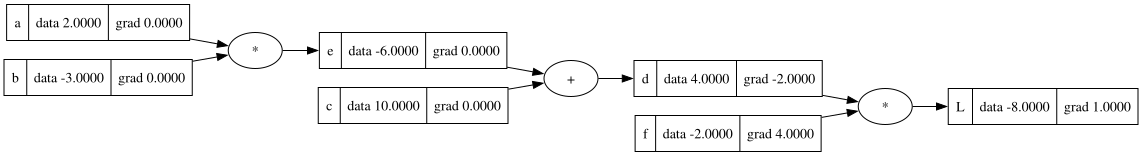

In [21]:
L.grad = 1.0
d.grad = f.data    # dL/dd = f = -2.0
f.grad = d.data    # dL/df = d =  4.0

draw_dot(L)

Grafikte artık `L`, `d` ve `f` kutularında gerçek gradyanlar görünüyor; `a`, `b`, `c`, `e` hâlâ sıfır — oralara henüz gelmedik.

Aynı zamanda bunu `lol()` fonksiyonunda **inline gradient check** olarak doğruluyoruz: `d`'yi `h` kadar artırıp sayısal gradyanı ölçüyoruz, elle bulduğumuz değerle karşılaştırıyoruz. Aynısını `f` için de yapıyoruz.

```
dL/dd ~= -1.9999999999953388     elle bulduğumuz: -2.0  ✅
dL/df ~=  3.9999999999995595     elle bulduğumuz:  4.0  ✅
```

Değerler doğru. Sondaki küçük sapmalar sonlu farklar yönteminin floating-point hatası — beklenen bir şey, elle yaptığımız hesap kesin olan.

Bundan sonra her adımda bu kontrolü tekrarlayacağız: bir kademe geriye gidip zincir kuralıyla gradyanı elle bul, sonra `lol()` ile doğrula.

In [22]:
def lol():

    h = 0.0001

    def build(dd=0.0, df=0.0):
        a = Value(2.0, label='a')
        b = Value(-3.0, label='b')
        c = Value(10.0, label='c')
        e = a*b; e.label = 'e'
        d = e + c; d.label = 'd'
        d.data += dd                      # d'yi h kadar oynat
        f = Value(-2.0 + df, label='f')   # ya da f'i
        L = d * f; L.label = 'L'
        return L.data

    L1 = build()
    print('dL/dd ~=', (build(dd=h) - L1) / h)
    print('dL/df ~=', (build(df=h) - L1) / h)

lol()

dL/dd ~= -1.9999999999953388
dL/df ~= 3.9999999999995595


## Manual backpropagation #2: chain rule

Şimdi sıra `dL/dc`'yi hesaplamaya geldi. **Eğer bunu anlarsak tüm backprop ve neural network olayını anlamış oluruz** — bu videonun en kritik yeri.

### Elimizde ne var?

En baştan biliyoruz ki `dL/dd = -2`. Bunu bir önceki adımda bulduk.

### `dd/dc`'yi hesaplayalım

Lise calculus kurallarından: `c + e = d` olduğuna göre, `d`'nin `c`'ye göre türevi **1** olur. Toplamada her terimin katsayısı 1'dir.

Limit tanımı da aynı sonucu verir:

```
[d(c + h) - d(c)] / h
((c + h + e) - (c + e)) / h
(c + h + e - c - e) / h
h / h
1
```

### Peki bu ikisi nasıl birleşiyor?

Şöyle düşün:

- `d`'yi biraz değiştirdiğimizde **`L`'deki oynamayı** ölçebiliyoruz. → `dL/dd = -2`
- `c`'yi biraz değiştirdiğimizde de **`d`'deki oynamayı** ölçüyoruz. → `dd/dc = 1`

Dolayısıyla burada calculus'taki **chain rule** (zincir kuralı) devreye giriyor. Yani bu derivative'leri çarpmamız gerekiyor:

$$\frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx}$$

George F. Simmons bunu çok güzel anlatıyor:

> "Bir araba bisikletten iki kat hızlıysa ve bisiklet de yürüyen bir adamdan dört kat hızlıysa, araba adamdan 2 × 4 = 8 kat hızlıdır."
>
> *— "if a car travels twice as fast as a bicycle and the bicycle is four times as fast as a walking man, then the car travels 2 × 4 = 8 times as fast as the man."*

Yani ara oranları çarparak uçtaki oranı buluyorsun. Bizim durumumuzda araba `L`, bisiklet `d`, yürüyen adam da `c`.

### Sonuç

```
dL/dc = dL/dd · dd/dc
      = -2 · 1
      = -2
```

Burada farkına varırsan `dd/dc` **1**. Yani kısaca `dL/dd`'yi kopyalıyoruz. Toplama durumu olunca hep böyle oluyor, çünkü zaten zincir kuralından gelen çarpan 1 ve 1 ile çarpmak etki etmiyor.

Bu çok önemli bir sezgi: **`+` düğümü gradyanı değiştirmez, olduğu gibi geriye dağıtır.** Gelen gradyanı bütün çocuklarına aynen kopyalar.

### `dL/de` de aynı

`e` için de tam olarak aynı hikâye — `d = e + c` toplamasında `dd/de = 1`:

```
dL/de = dL/dd · dd/de = -2 · 1 = -2
```

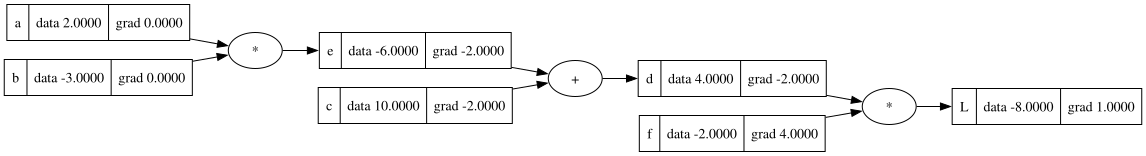

In [23]:
c.grad = -2.0    # dL/dc = dL/dd * dd/dc = -2 * 1
e.grad = -2.0    # dL/de = dL/dd * dd/de = -2 * 1

draw_dot(L)

`+` düğümünün gradyanı olduğu gibi kopyaladığını grafikte de görüyoruz: `d`, `c` ve `e` kutularının üçünde de `grad -2.0000` yazıyor.

Dolayısıyla `dL/dc` **-2** oluyor. Bunu `lol()` verifier'dan geçirdiğimizde gene küsuratlı bir -2 görebiliyoruz:

```
dL/dc ~= -1.9999999999953388     elle bulduğumuz: -2.0  ✅
dL/de ~= -1.9999999999953388     elle bulduğumuz: -2.0  ✅
```

Küsurat yine sonlu farklar yönteminin floating-point hatası; elle zincir kuralıyla bulduğumuz -2 kesin olan.

In [24]:
def lol():

    h = 0.0001

    def build(dc=0.0, de=0.0):
        a = Value(2.0, label='a')
        b = Value(-3.0, label='b')
        c = Value(10.0 + dc, label='c')
        e = a*b; e.label = 'e'
        e.data += de
        d = e + c; d.label = 'd'
        f = Value(-2.0, label='f')
        L = d * f; L.label = 'L'
        return L.data

    L1 = build()
    print('dL/dc ~=', (build(dc=h) - L1) / h)
    print('dL/de ~=', (build(de=h) - L1) / h)

lol()

dL/dc ~= -1.9999999999953388
dL/de ~= -1.9999999999953388


## Manual backpropagation #3: `dL/da` ve `dL/db`

Şimdi `dL/da`'yı hesaplayalım. Grafikte en sola, yaprak node'lara geldik.

`dL/de`'yi zaten hesapladık: **-2**.

Zincir kuralını yine aynı şekilde kuruyoruz:

```
dL/da = (dL/de) · (de/da)
```

`e = a * b` olduğuna göre, o zaman `de/da` **b** olur, `de/db` de **a** olur. Çarpımda bir çarpanın türevi diğer çarpandır.

Yani:

```
a.grad = b · (dL/de) = (-3) · (-2) =  6
b.grad = a · (dL/de) = ( 2) · (-2) = -4
```

### Burada `+` ile `*` arasındaki fark ortaya çıkıyor

Bir önceki adımda `+` düğümü gradyanı olduğu gibi kopyalıyordu, çünkü yerel türevi 1'di.

Burada ise `*` düğümü gradyanı **karşı çarpanla çarpıyor**. `a`'ya giden gradyan `b`'nin değeriyle, `b`'ye giden gradyan `a`'nın değeriyle çarpılıyor. İşaret bile değişebiliyor: `-2` gelen gradyan, `a` tarafında `+6` olarak çıkıyor.

Bu iki kural — `+` kopyalar, `*` karşı çarpanla çarpar — birazdan `_backward` fonksiyonlarına yazacağımız şeyin ta kendisi.

### Kapanış

`dL/da = 6` sonucu, en başta `lol()` ile sayısal olarak bulduğumuz `6.000000000021544` ile örtüşüyor. O zaman kaba kuvvetle ölçmüştük, şimdi zincir kuralıyla türettik.

Artık grafikteki bütün node'ların gradyanı elimizde. Backpropagation'ı baştan sona elle yapmış olduk.

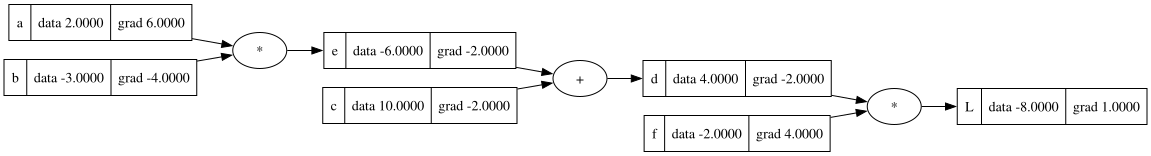

In [25]:
a.grad = b.data * e.grad    # dL/da = de/da * dL/de = -3 * -2 =  6
b.grad = a.data * e.grad    # dL/db = de/db * dL/de =  2 * -2 = -4

draw_dot(L)

`lol()` ile son bir inline gradient check.

In [26]:
def lol():

    h = 0.0001

    def build(da=0.0, db=0.0):
        a = Value(2.0 + da, label='a')
        b = Value(-3.0 + db, label='b')
        c = Value(10.0, label='c')
        e = a*b; e.label = 'e'
        d = e + c; d.label = 'd'
        f = Value(-2.0, label='f')
        L = d * f; L.label = 'L'
        return L.data

    L1 = build()
    print('dL/da ~=', (build(da=h) - L1) / h)
    print('dL/db ~=', (build(db=h) - L1) / h)

lol()

dL/da ~= 6.000000000021544
dL/db ~= -4.000000000008441


```
dL/da ~=  6.000000000021544     elle bulduğumuz:  6  ✅
dL/db ~= -4.000000000008441     elle bulduğumuz: -4  ✅
```

Hepsi tutuyor. Özet olarak grafikteki bütün gradyanlar:

| node | data | grad | nasıl bulundu |
|------|------|------|----------------|
| `L`  | -8.0 |  1.0 | `dL/dL = 1` (başlangıç) |
| `d`  |  4.0 | -2.0 | `dL/dd = f` |
| `f`  | -2.0 |  4.0 | `dL/df = d` |
| `c`  | 10.0 | -2.0 | `+` kopyaladı |
| `e`  | -6.0 | -2.0 | `+` kopyaladı |
| `a`  |  2.0 |  6.0 | `*` ile `b`'yi çarptı |
| `b`  | -3.0 | -4.0 | `*` ile `a`'yı çarptı |

### Gradyanı kullanmak: `L`'yi artırmak

Şimdi input'larımızı değiştirerek `L`'nin değerini artırmak istiyoruz. Dolayısıyla **gradyanın yönüne gitmeliyiz**.

Her input için şunu yapıyoruz:

```python
a.data += 0.01 * a.grad
```

Aynısını `b`, `c` ve `f` için de yapıyoruz. Bu, `L`'de artma yapacak.

Neden işe yarıyor? Çünkü `a.grad = 6` demek "`a`'yı artırırsam `L` de artar" demek. `b.grad = -4` ise "`b`'yi artırırsam `L` azalır" — o yüzden `b`'ye negatif bir miktar eklenmiş oluyor ve `b` küçülüyor. Her değişken, gradyanının söylediği yöne doğru itiliyor.

Sadece **yaprak node'ları** oynatıyoruz: `a`, `b`, `c`, `f`. `e`, `d` ve `L` zaten bunlardan hesaplanan ara değerler, o yüzden forward pass'i baştan çalıştırıp yeni `L`'yi buluyoruz.

Buradaki `0.01` **step size** (adım büyüklüğü). Gradyan sadece *yönü* söylüyor, ne kadar gidileceğini değil. Çok büyük seçersek türevin geçerli olduğu küçük bölgenin dışına çıkarız.

In [27]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


Bunu çıktıda da görebiliyoruz:

```
önce:  L = -8.0
sonra: L = -7.286496
```

`L` gerçekten arttı. Gradyanın yönüne gittik ve işe yaradı.

> **Tabii ki gerçek bir neural network'te loss function'ı düşürmek isteriz.** Orada bu satırların önünde eksi işareti olacak:
>
> ```python
> p.data += -learning_rate * p.grad
> ```
>
> Yani gradyanın *tersi* yöne gideceğiz. Buna **gradient descent** deniyor. Burada `L`'yi artırmak için yaptığımız şeyin işaret çevrilmiş hâli — mekanizma birebir aynı.

## Manual backpropagation example #2: a neuron

Şimdi daha yararlı bir örneğe geçiyoruz.

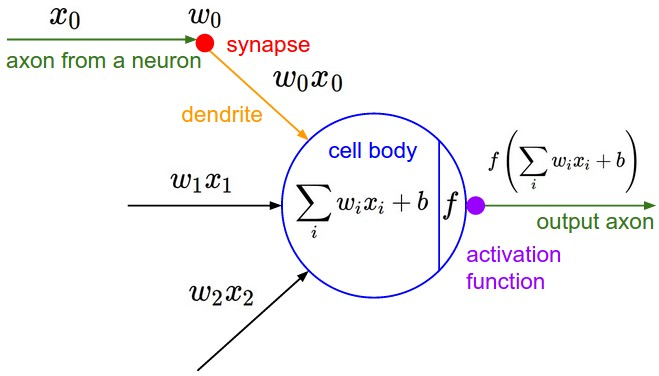

Burada `x1` ve `x2` input, `w1` ve `w2` de onların ağırlığı. Cell body'e bir sürü bu input ve parametrelerden giriyor; içindeki `b` de o neuron'un *trigger happiness* tarzı bir metriği.

Yani tüm `w0·x0`, `w1·x1` vs. hepsini çarpıp topluyoruz, sonra bir activation fonksiyonuna veriyoruz — sigmoid veya tanh fonksiyonları gibi.

$$f\left(\sum_i w_i x_i + b\right)$$

> **Küçük düzeltme:** "hepsini çarpıyoruz" derken kastettiğin her `wᵢ`'yi kendi `xᵢ`'si ile çarpmak; ardından bu çarpımların hepsi **toplanıyor** ve üstüne `b` ekleniyor. Formüldeki `Σ` bu toplama.
>
> `b` (bias) neuron'un ne kadar kolay ateşlendiğini ayarlıyor: büyükse input'lar zayıf olsa bile çıktı yüksek olur, negatifse neuron'u susturur. "Trigger happiness" tam olarak bunu anlatıyor.

### tanh

İşte bu tanh fonksiyonu. Tüm sayıları **-1 ile 1 arasına sıkıştırıyor**.

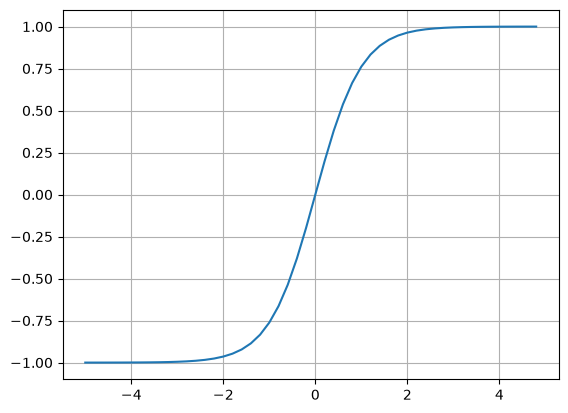

In [28]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();

Grafikte görüldüğü gibi girdi ne kadar büyürse büyüsün çıktı 1'i geçmiyor, ne kadar küçülürse küçülsün -1'in altına inmiyor. Uçlarda eğri neredeyse düzleşiyor.

Dolayısıyla yine tanh türev kuralını `Value` sınıfının içine, hem **forward pass**'i hem de **derivative**'ini not alıyoruz.

Forward pass için tanh'ın tanımı:

$$\tanh(x) = \frac{e^{2x} - 1}{e^{2x} + 1}$$

Türevi ise şu — ve güzelliği, sonucun kendisiyle ifade edilebilmesi:

$$\frac{d}{dx}\tanh(x) = 1 - \tanh(x)^2$$

Yani `o = n.tanh()` ise `do/dn = 1 - o²`. Çıktıyı zaten hesapladığımız için türev bedavaya geliyor.

> Buradan da anlaşılıyor ki `o` neden ±1'e yaklaşırsa türev sıfıra yaklaşıyor: `1 - 1² = 0`. Daha önce konuştuğumuz "gradyan sıfırsa öğrenme durur" durumu tam olarak bu — tanh doygunluğu.

**Ne değişti?** `Value` sınıfına yeni bir metot:

```diff
+ def tanh(self):
+     x = self.data
+     t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
+     out = Value(t, (self, ), 'tanh')
+     return out
```

Dikkat: `_children` olarak `(self, )` veriyoruz — tanh tek girdili, `__add__` ve `__mul__` gibi iki çocuğu yok.

In [29]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        return out

### Neuron'u kuralım

İki input'lu bir neuron: `o = tanh(x1·w1 + x2·w2 + b)`

> `b` değeri `6.8813735870195432` gelişigüzel değil — Karpathy bunu, çıkan sayılar yuvarlak olsun diye özellikle seçiyor. Birazdan `o` tam `0.7071` çıkacak.

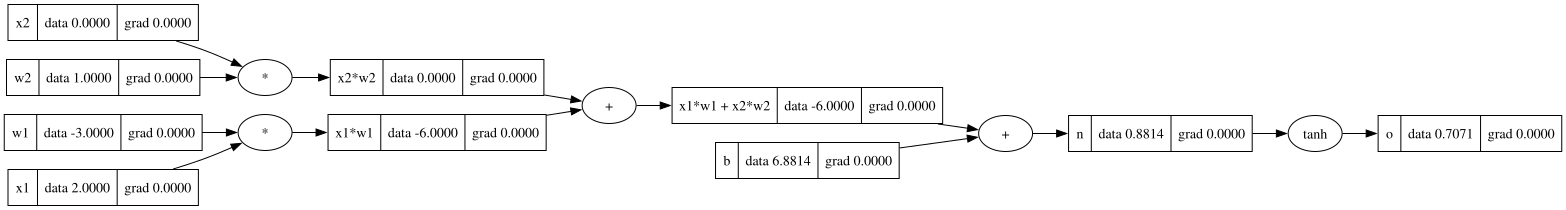

In [30]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

draw_dot(o)

Şimdi bu grafiğe backpropagation yapacağız. Sonra `+` node'lara grad'ları dağıtıp, `*` node'lara da "içinin türevi × o zamana kadar olan grad" yöntemiyle tüm expression graph'a grad'ları dağıtıyoruz.